In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,roc_auc_score,roc_curve,classification_report
from sklearn.preprocessing import LabelEncoder

In [129]:
data=pd.read_csv("/content/digital_marketing_campaign_dataset.csv")
df=pd.DataFrame(data)
print(df.head())
print(df.isnull().sum())
print(df.groupby("Conversion")["ConversionRate"].describe())
print(df.groupby("Conversion")["ClickThroughRate"].describe())

   CustomerID  Age  Gender  Income CampaignChannel CampaignType      AdSpend  \
0        8000   56  Female  136912    Social Media    Awareness  6497.870068   
1        8001   69    Male   41760           Email    Retention  3898.668606   
2        8002   46  Female   88456             PPC    Awareness  1546.429596   
3        8003   32  Female   44085             PPC   Conversion   539.525936   
4        8004   60  Female   83964             PPC   Conversion  1678.043573   

   ClickThroughRate  ConversionRate  WebsiteVisits  PagesPerVisit  TimeOnSite  \
0          0.043919        0.088031              0       2.399017    7.396803   
1          0.155725        0.182725             42       2.917138    5.352549   
2          0.277490        0.076423              2       8.223619   13.794901   
3          0.137611        0.088004             47       4.540939   14.688363   
4          0.252851        0.109940              0       2.046847   13.993370   

   SocialShares  EmailOpens  Ema

In [130]:
encoder=LabelEncoder()
df["Gender"]=encoder.fit_transform(df["Gender"])
df=pd.get_dummies(df,columns=["CampaignChannel","CampaignType"])
df["email_engagement"] = df["EmailClicks"] / (df["EmailOpens"] + 1)
df["engagement_score"] = (df["PagesPerVisit"]*df["TimeOnSite"])
df["customer_value"] = (df["PreviousPurchases"]*df["LoyaltyPoints"])
df["marketing_efficiency"] = (df["ClickThroughRate"]*df["TimeOnSite"])
df["spend_per_visit"] = (df["AdSpend"]/(df["WebsiteVisits"]+1))
X=df.drop(["CustomerID","Conversion","AdvertisingPlatform","AdvertisingTool"],axis=1)
Y=df["Conversion"]
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)


In [131]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train_scaled,Y_train)
y_pred = model1.predict(X_test_scaled)
print(confusion_matrix(Y_test,y_pred))
print(classification_report(Y_test,y_pred))
y_prob = model1.predict_proba(X_test_scaled)[:,1]

print(roc_auc_score(Y_test, y_prob))

[[  38  156]
 [  22 1384]]
              precision    recall  f1-score   support

           0       0.63      0.20      0.30       194
           1       0.90      0.98      0.94      1406

    accuracy                           0.89      1600
   macro avg       0.77      0.59      0.62      1600
weighted avg       0.87      0.89      0.86      1600

0.7911674561159098


In [132]:
model2 = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model2.fit(X_train_scaled,Y_train)
y_pred = model2.predict(X_test_scaled)
print(confusion_matrix(Y_test,y_pred))
print(classification_report(Y_test,y_pred))
y_prob = model2.predict_proba(X_test_scaled)[:,1]

print(roc_auc_score(Y_test, y_prob))

[[ 144   50]
 [ 399 1007]]
              precision    recall  f1-score   support

           0       0.27      0.74      0.39       194
           1       0.95      0.72      0.82      1406

    accuracy                           0.72      1600
   macro avg       0.61      0.73      0.60      1600
weighted avg       0.87      0.72      0.77      1600

0.7883041750377615


In [133]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": model1.coef_[0]
})

coef_df["abs_coef"] = abs(coef_df["coef"])

coef_df.sort_values(
    by="abs_coef",
    ascending=False
).head(20)

,feature,coef,abs_coef
8,TimeOnSite,0.661050,0.661050
4,ClickThroughRate,0.560364,0.560364
11,EmailClicks,0.501958,0.501958
10,EmailOpens,0.499622,0.499622
3,AdSpend,0.482345,0.482345
7,PagesPerVisit,0.448559,0.448559
12,PreviousPurchases,0.405171,0.405171
13,LoyaltyPoints,0.383880,0.383880
5,ConversionRate,0.352360,0.352360
21,CampaignType_Conversion,0.319675,0.319675


<Axes: xlabel='CampaignChannel'>

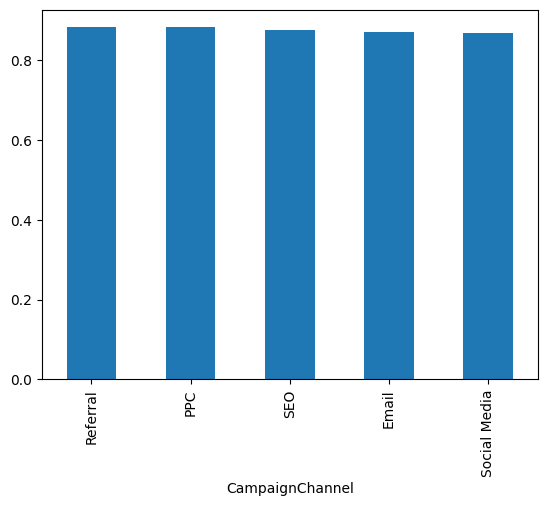

In [134]:
df1=pd.DataFrame(data)
channel_conv = (df1.groupby("CampaignChannel")["Conversion"].mean().sort_values(ascending=False))
channel_conv.plot(kind="bar")

<Axes: xlabel='CampaignType'>

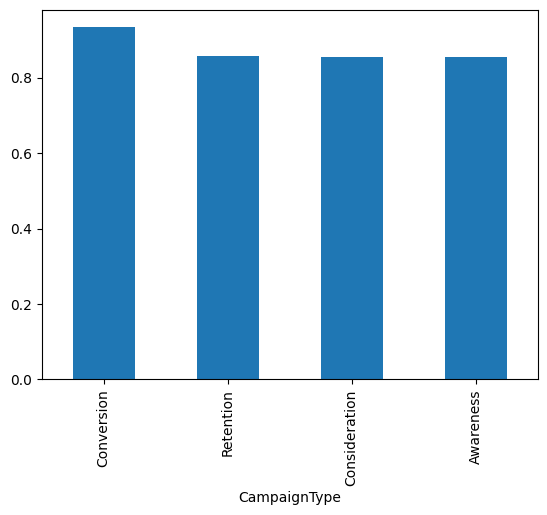

In [135]:
campaign_conv = (df1.groupby("CampaignType")["Conversion"].mean().sort_values(ascending=False))
campaign_conv.plot(kind="bar")

<Axes: xlabel='Conversion', ylabel='TimeOnSite'>

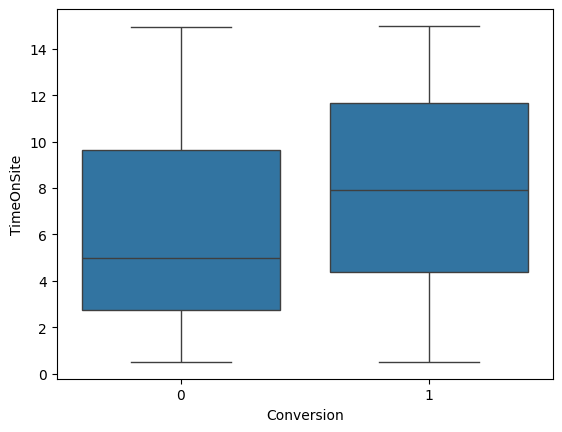

In [136]:
sns.boxplot(x="Conversion",y="TimeOnSite",data=df1)

<Axes: xlabel='Conversion', ylabel='PreviousPurchases'>

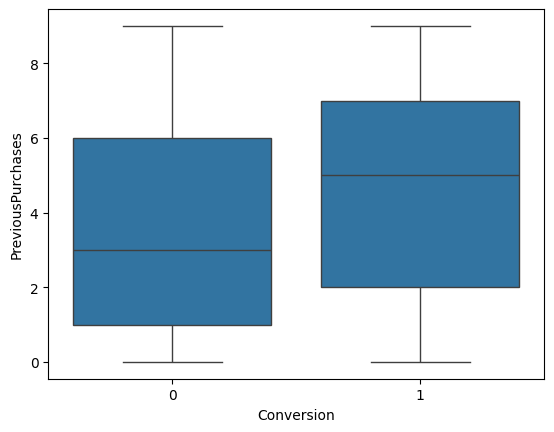

In [137]:
sns.boxplot(x="Conversion",y="PreviousPurchases",data=df)

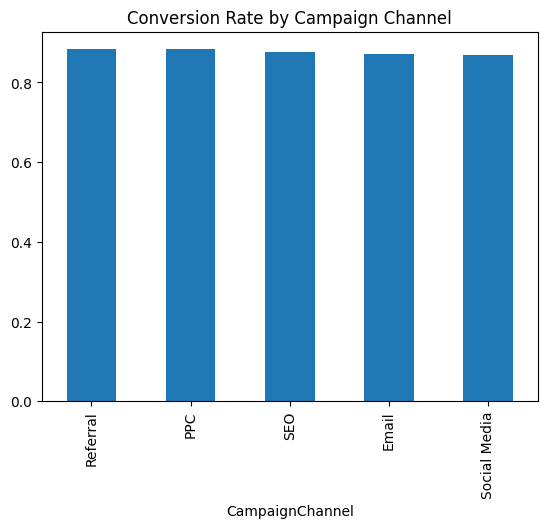

In [138]:
channel_conv = (df1.groupby("CampaignChannel")["Conversion"].mean().sort_values(ascending=False))
channel_conv.plot(kind="bar")
plt.title("Conversion Rate by Campaign Channel")
plt.show()

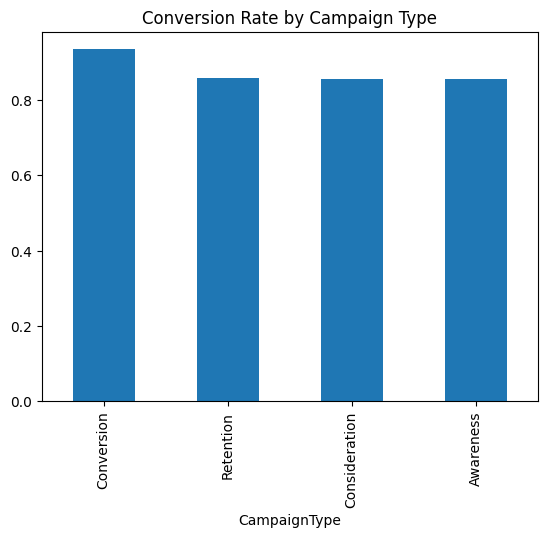

In [139]:
campaign_conv = (df1.groupby("CampaignType")["Conversion"].mean().sort_values(ascending=False))
campaign_conv.plot(kind="bar")
plt.title("Conversion Rate by Campaign Type")
plt.show()